In [2]:
# ==========================================
# Renewable Energy Generation Forecasting
# Solar Power Prediction using Random Forest
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score




In [5]:
generation = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Plant_1_Generation_Data.csv")
weather = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Plant_1_Weather_Sensor_Data.csv")

print("Generation Data Shape:", generation.shape)
print("Weather Data Shape:", weather.shape)


Generation Data Shape: (68778, 7)
Weather Data Shape: (3182, 6)


In [6]:
generation['DATE_TIME'] = pd.to_datetime(
    generation['DATE_TIME'],
    format='%d-%m-%Y %H:%M'
)

weather['DATE_TIME'] = pd.to_datetime(
    weather['DATE_TIME'],
    format='%Y-%m-%d %H:%M:%S'
)

# Merge datasets
data = pd.merge(
    generation,
    weather,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

print("\nMerged Data Shape:", data.shape)


Merged Data Shape: (68774, 11)


In [7]:
data = data.dropna()

data = data.drop_duplicates()

In [8]:
data['HOUR'] = data['DATE_TIME'].dt.hour
data['DAY'] = data['DATE_TIME'].dt.day
data['MONTH'] = data['DATE_TIME'].dt.month

X = data[
    [
        'AMBIENT_TEMPERATURE',
        'MODULE_TEMPERATURE',
        'IRRADIATION',
        'HOUR',
        'DAY',
        'MONTH'
    ]
]


y = data['AC_POWER']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [11]:
predictions = model.predict(X_test)


In [12]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("\n===== MODEL PERFORMANCE =====")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


===== MODEL PERFORMANCE =====
MAE : 16.373119937057847
MSE : 2085.7284126212594
RMSE: 45.66977570145555
R2 Score: 0.9864830291578847


In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance)


Feature Importance:
               Feature  Importance
2          IRRADIATION    0.995943
1   MODULE_TEMPERATURE    0.001334
4                  DAY    0.000980
0  AMBIENT_TEMPERATURE    0.000968
3                 HOUR    0.000708
5                MONTH    0.000067


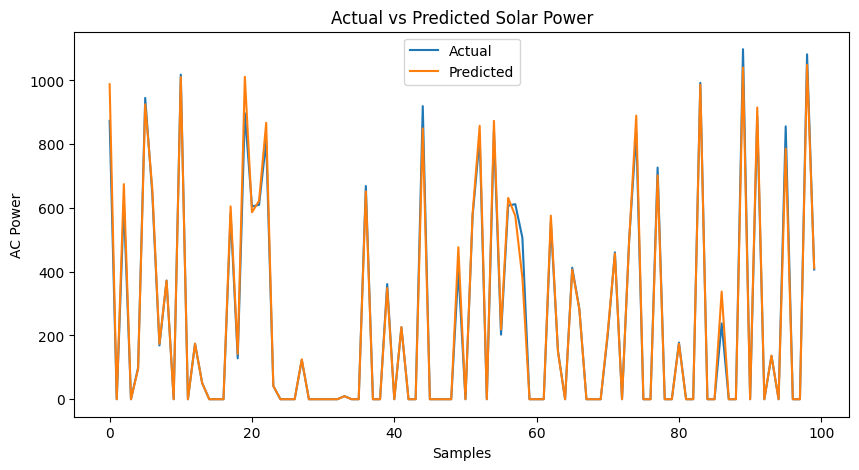

In [14]:
plt.figure(figsize=(10,5))
plt.plot(
    y_test.values[:100],
    label='Actual'
)
plt.plot(
    predictions[:100],
    label='Predicted'
)
plt.title('Actual vs Predicted Solar Power')
plt.xlabel('Samples')
plt.ylabel('AC Power')
plt.legend()
plt.show()

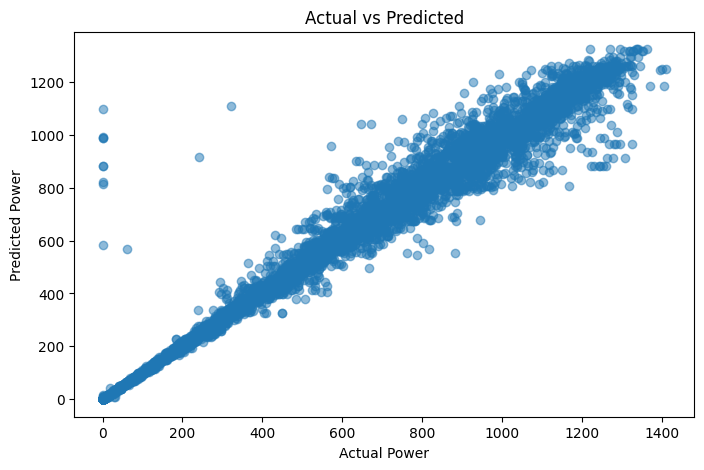

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted")
plt.show()


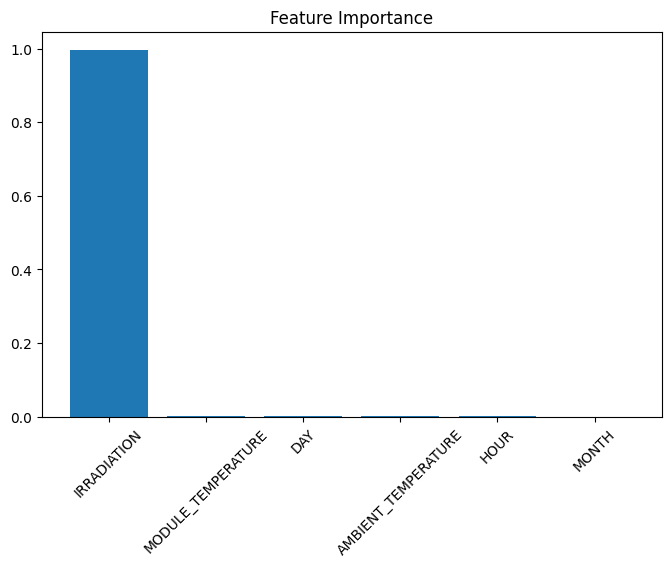

In [16]:
plt.figure(figsize=(8,5))
plt.bar(
    importance['Feature'],
    importance['Importance']
)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [17]:
new_data = pd.DataFrame({
    'AMBIENT_TEMPERATURE':[30],
    'MODULE_TEMPERATURE':[35],
    'IRRADIATION':[0.8],
    'HOUR':[12],
    'DAY':[15],
    'MONTH':[6]
})

predicted_power = model.predict(new_data)

print("\nPredicted Solar Power:")
print(predicted_power[0])


Predicted Solar Power:
1025.2801406516905


In [18]:
import joblib

joblib.dump(
    model,
    "solar_power_model.pkl"
)

print("\nModel saved as solar_power_model.pkl")


Model saved as solar_power_model.pkl
